In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

import torch

sys.path.append('../..')
import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

## Load data & compute treatment effects

In [3]:
data = slk.datasets.replogle()

In [4]:
perturbations = set(np.unique(data.obs[slk.configs.get_config('pert_key')].values))
print("Perturbations:", len(perturbations))

pathways = []
for pathway in data.uns['pathways'].values():
    pathways.append(set(pathway))
print("Pathways:", len(pathways))

Perturbations: 682
Pathways: 8


In [5]:
slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect'
)

100%|██████████| 681/681 [00:08<00:00, 80.05it/s]


## Train ContrastiveVI

Architecture (Weinberger et al. 2023) — three variables:
- **Background latent z**: `q(z | x)` via `z_encoder` — shared variation in all cells
- **Salient latent t**: `q(t | x)` via `s_encoder` — perturbation-specific; NTC cells trained with **t = 0** (Dirac δ(0))
- **Batch covariate s**: observed batch index (no encoder; passed directly to decoder)
- **Decoder** `p(x | z, t, s)`: reconstructs from `cat([z, t])`

scvi naming: scvi's `s_encoder` → paper's **t** (salient). scvi's `batch_index` → paper's **s** (batch covariate).

**Sherlock extension**: replaces the universal `N(0, I)` prior on `t` for target cells with a learned
per-perturbation prior `p(t | p) = N(μ_p, diag(exp(log_var_p)))`.
Initialized to `N(0, I)` so early training is identical to vanilla ContrastiveVI.
The trained `μ_p` vectors are used directly as counterfactual shifts.

`run_single` returns a `ContrastiveVI` instance (inherits both `ContrastiveVAE` and `PerturbModelBase`)
— no separate wrapper needed.

In [11]:
results = slk.tl.run_single(
    data,
    model='contrastivevi',
    num_epochs=200,
    batch_size=4096,
    n_background_latent=16,
    n_salient_latent=16,
)
model = results['model']

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 200/200: 100%|██████████| 200/200 [52:46<00:00, 15.59s/it, v_num=1, train_loss_step=3.42e+3, train_loss_epoch=3.53e+3]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|██████████| 200/200 [52:46<00:00, 15.83s/it, v_num=1, train_loss_step=3.42e+3, train_loss_epoch=3.53e+3]


## Save & load

Save and reload the trained `ContrastiveVI` model using sherlock's unified checkpoint utilities.

In [12]:
os.makedirs('../results', exist_ok=True)
slk.tl.save_results(results, '../results/contrastivevi_model.pt')

In [6]:
model = slk.tl.load_results('../results/contrastivevi_model.pt')

## Evaluate

`z` stores the **salient** latent `t = E[q(t|x)]` per cell — the perturbation-specific representation
(paper's **t**; scvi calls it `s_encoder` output).

`rho_corr` is the Pearson correlation of pseudobulk mean salient vectors `t̂_p` across perturbations.
Because both `z_corr` and `rho_corr` use pseudobulk mean `t`, they should be identical (`r ≈ 1`).

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
slk.tl.eval_single(model, data, obsm_key="z", uns_key="results", device=device)
data.uns['results'].keys()

dict_keys(['z_corr', 'perts', 'rho_corr', 'rho_perts', 'rho_embed'])

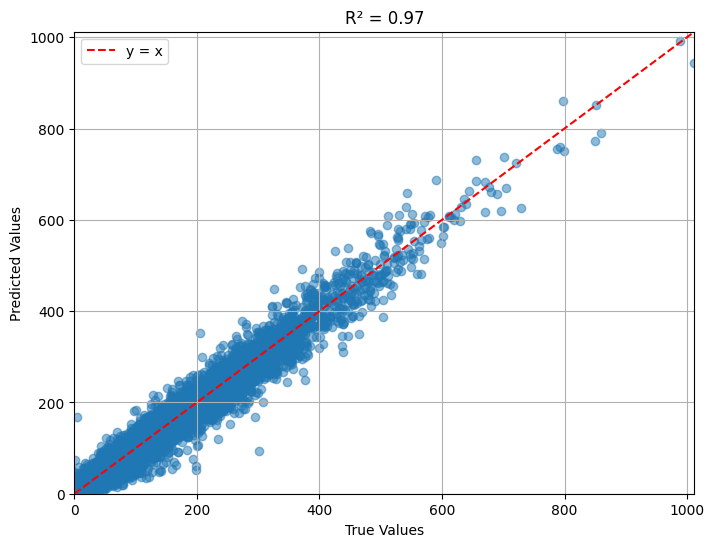

In [15]:
slk.pl.plot_r2(data)

## UMAP of salient latent t

Each point is a perturbed cell. The salient latent `t = E[q(t|x)]` (paper's **t**; scvi: `s_encoder`) captures variation specific to each perturbation.

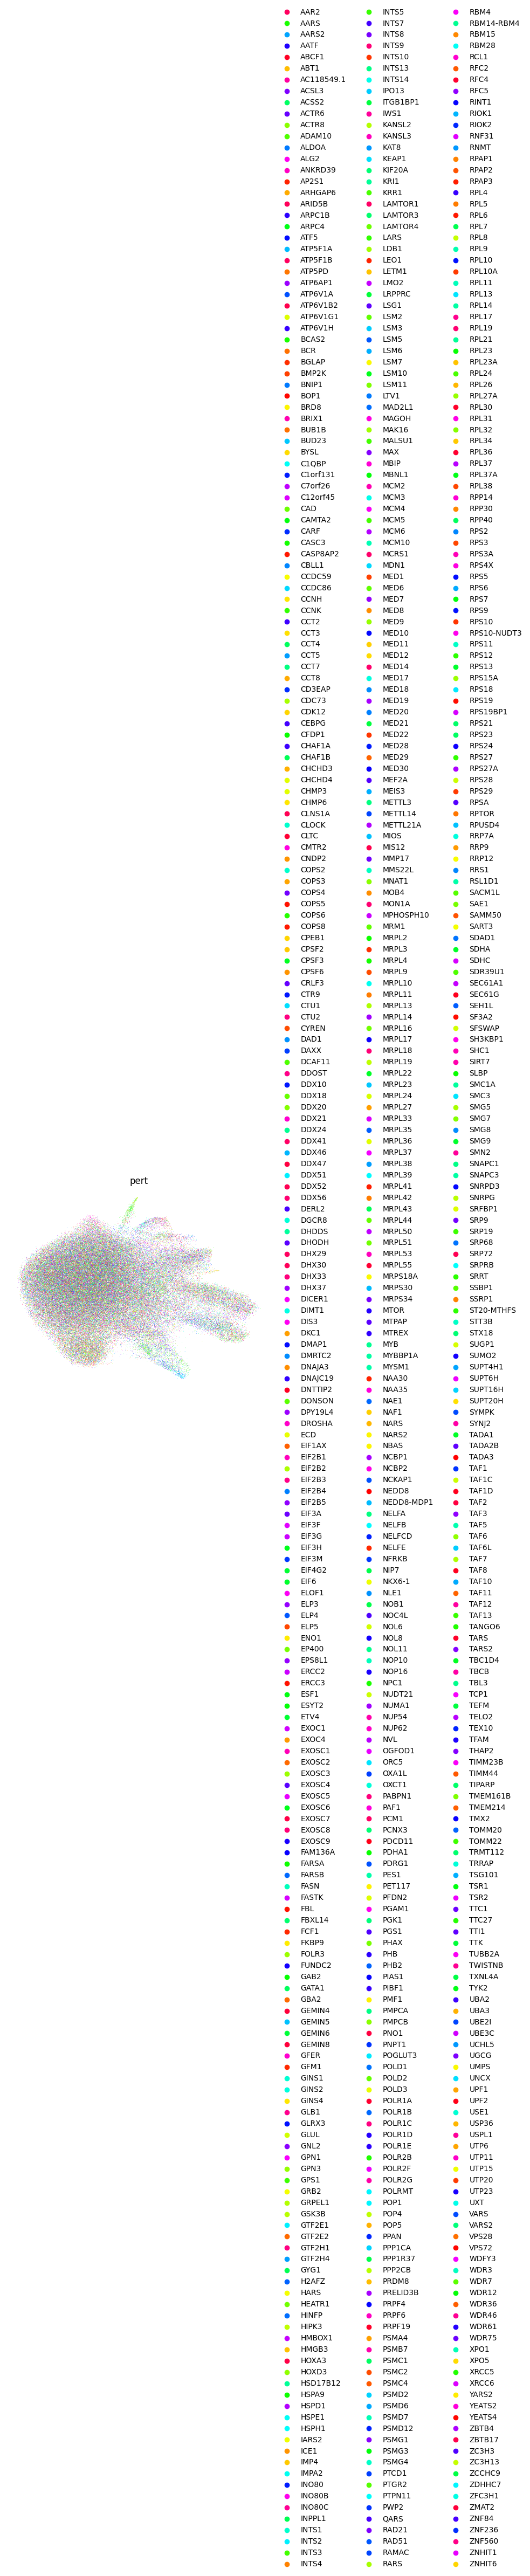

In [21]:
p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

sub = data[data.obs[p_key] != NTC]
sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

import random
n_cats = sub.obs[p_key].nunique()
palette = sns.color_palette("hsv", n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub, color='pert', palette=palette, frameon=False)

## Perturbation embedding correlation (rho_corr)

`rho_corr` is computed from pseudobulk mean salient vectors `ŝ_p` — the model's perturbation similarity.

/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


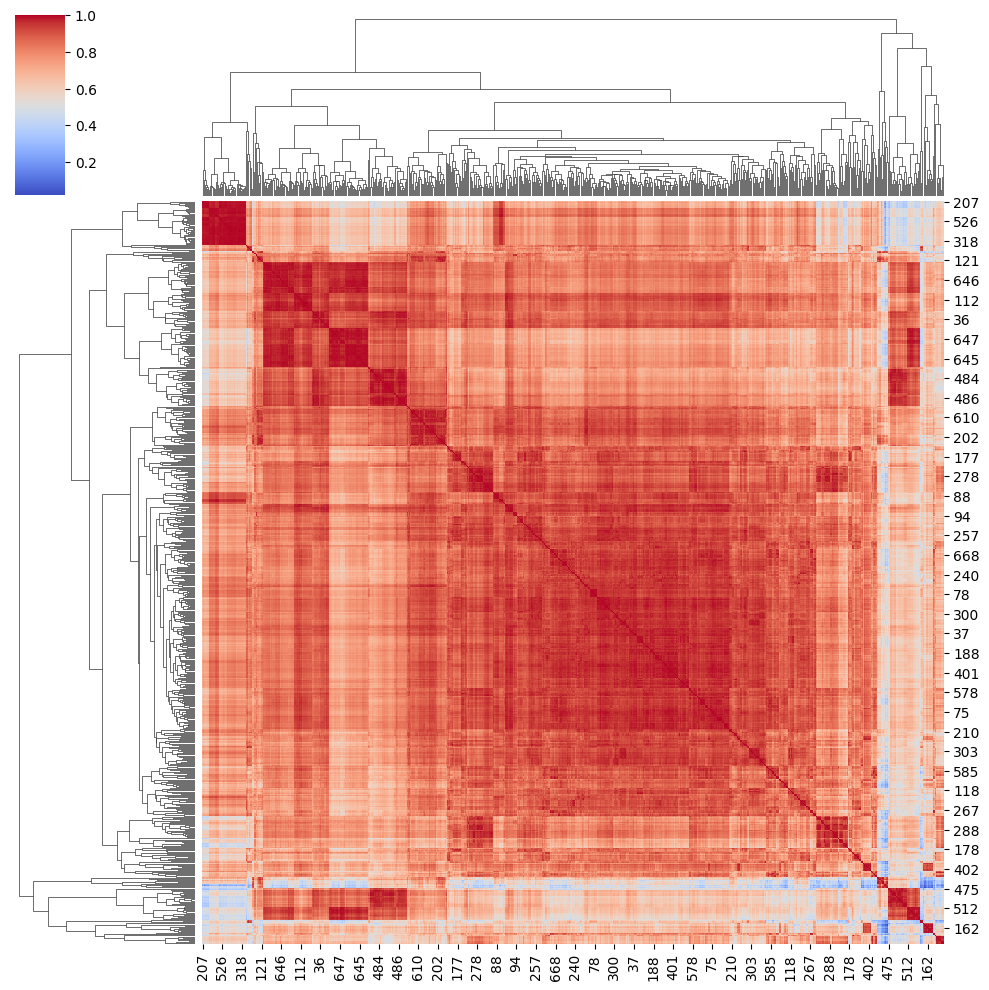

In [17]:
slk.pl.plot_corr(data)

## ATE — counterfactual effect prediction

Uses `predict_counterfactual_effects` with the learned per-perturbation prior:

1. Abduct background `z` from NTC cells: `E[q(z | x_NTC)]`
2. K-means cluster the abducted `z` → centroids `c_k` with weights `w_k`
3. For each perturbation `p`, apply shift `μ_p` (the learned prior mean from `pert_mu`):
   `x_cf(p) = Σ_k w_k · decode(cat([c_k, μ_p]))`
4. NTC baseline: `x_base = Σ_k w_k · decode(cat([c_k, 0]))` (t = 0, Dirac prior)
5. Predicted ATE: `Δ(p) = lognorm(x_cf(p)) − lognorm(x_base)`

`μ_p` is learned jointly with the encoder/decoder by replacing the standard `KL(q(t|x) ∥ N(0,I))`
with `KL(q(t|x) ∥ N(μ_p, exp(log_var_p)))` for target cells during training.

In [8]:
ate = model.predict_counterfactual_effects(
    data,
    n_centroids=25,
    observed_effect=data.uns['treat_effect'],
)
print("Pearson r (predicted vs observed ATE):", ate['corr'])

Pearson r (predicted vs observed ATE): 0.37183016538619995


## z_corr vs rho_corr consistency

For ContrastiveVI, both are computed from pseudobulk mean salient `t`, so they should be identical (r ≈ 1).

In [9]:
z_corr   = data.uns['results'].get('z_corr')
rho_corr = data.uns['results'].get('rho_corr')

from scipy.stats import pearsonr, spearmanr

pearson  = pearsonr(z_corr.flatten(),  rho_corr.flatten())
spearman = spearmanr(z_corr.flatten(), rho_corr.flatten())

print(f"Spearman ρ = {spearman[0]:.3f}  (p = {spearman[1]:.1e})")
print(f" Pearson  r = {pearson[0]:.3f}  (p = {pearson[1]:.1e})")

Spearman ρ = 1.000  (p = 0.0e+00)
 Pearson  r = 1.000  (p = 0.0e+00)


## Replogle pathway clustering

Subset `rho_corr` (correlation of `ŝ_p` vectors) to pathway genes, then cluster.

In [10]:
rho_perts = data.uns['results']['rho_perts']
print(f"rho_corr shape: {rho_corr.shape}, perts: {len(rho_perts)}")

rho_corr shape: (681, 681), perts: 681


In [11]:
C = z_corr

In [12]:
all_genes = [gene for genes in data.uns['pathways'].values() for gene in genes]

rho_perts_list = list(rho_perts)
gene_ids = [rho_perts_list.index(g) for g in all_genes if g in rho_perts_list]
pathway_genes_found = [g for g in all_genes if g in rho_perts_list]

print(f"Found {len(pathway_genes_found)} / {len(all_genes)} pathway genes in rho_perts")
cov_subset = C[np.ix_(gene_ids, gene_ids)].clip(-1, 1)

Found 335 / 335 pathway genes in rho_perts


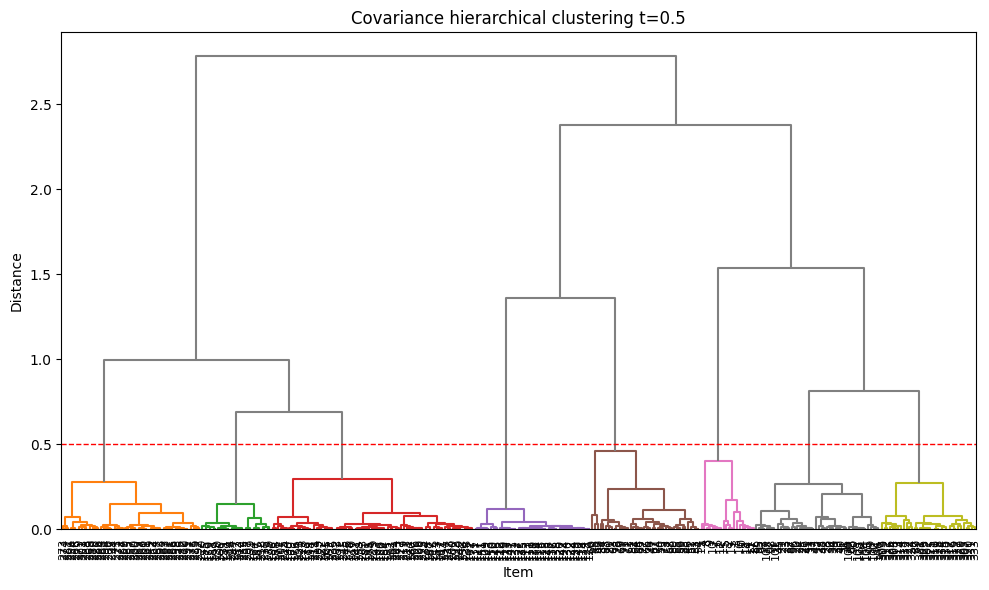

In [14]:
groups = slk.tl.cluster_rho(data, t=0.5, rho_corr=cov_subset, show=True)

In [15]:
named_groups = slk.tl.group2name(groups, pathway_genes_found)
named_groups

,group
ZC3H3,6
ZFC3H1,6
CAMTA2,6
DHX29,6
DIS3,6
...,...
SNRPG,8
TIPARP,8
TTC27,8
TXNL4A,8


## Clustering metrics vs ground-truth pathways

In [16]:
from collections import Counter

gene_counts  = Counter(pathway_genes_found)
shared_genes = [gene for gene, count in gene_counts.items() if count > 1]
if shared_genes:
    print(f"⚠️  {len(shared_genes)} genes shared across pathways: {shared_genes[:10]}")
else:
    print("✅ Each gene appears in exactly one pathway.")

perts_df = pd.DataFrame(groups, index=pathway_genes_found, columns=['cluster'])

gene_to_pathway = {
    gene: pathway
    for pathway, genes in data.uns['pathways'].items()
    for gene in genes
    if gene in rho_perts_list
}
pathway_df = pd.DataFrame.from_dict(gene_to_pathway, orient='index', columns=['cluster'])

perts_df   = perts_df.drop(shared_genes, errors='ignore')
pathway_df = pathway_df.drop(shared_genes, errors='ignore')

print(f"perts_df: {perts_df.shape}  |  pathway_df: {pathway_df.shape}")

✅ Each gene appears in exactly one pathway.
perts_df: (335, 1)  |  pathway_df: (335, 1)


In [17]:
pathway_df['gene'] = pathway_df.index.copy()
pathway_df.columns = ['pathway', 'gene']

perts_aligned = perts_df.loc[pathway_df.index].copy()
perts_aligned['gene'] = perts_aligned.index.copy()

In [18]:
from sklearn.metrics import (
    adjusted_rand_score, adjusted_mutual_info_score,
    homogeneity_completeness_v_measure, silhouette_score,
    precision_score, recall_score, f1_score,
)
from scipy.optimize import linear_sum_assignment


def align_and_summarize(
    clusters_df, pathways_df,
    gene_col='gene', cluster_col='cluster', pathway_col='pathway',
    min_pathway_size=1, gene_embeddings=None,
):
    df = pd.merge(
        clusters_df[[gene_col, cluster_col]],
        pathways_df[[gene_col, pathway_col]],
        on=gene_col, how='inner', validate='one_to_one'
    ).dropna(subset=[cluster_col, pathway_col]).copy()

    if min_pathway_size > 1:
        keep = df[pathway_col].value_counts()
        df = df[df[pathway_col].isin(keep[keep >= min_pathway_size].index)].copy()

    y_true = df[pathway_col].astype(str).values
    y_pred = df[cluster_col].astype(str).values
    true_labels = np.unique(y_true)
    pred_labels = np.unique(y_pred)

    C = pd.crosstab(df[pathway_col].astype(str), df[cluster_col].astype(str))
    contingency_df = C.reindex(index=true_labels, columns=pred_labels, fill_value=0)

    M = contingency_df.values
    row_ind, col_ind = linear_sum_assignment(M.max() - M)
    mapping = {pred_labels[j]: true_labels[i] for i, j in zip(row_ind, col_ind)}
    for cl in pred_labels:
        if cl not in mapping:
            cl_mask = df[cluster_col].astype(str) == cl
            if cl_mask.any():
                mapping[cl] = df.loc[cl_mask, pathway_col].mode().iloc[0]

    mapped   = np.array([mapping.get(cl, None) for cl in y_pred], dtype=object)
    is_match = mapped == y_true
    accuracy  = float(is_match.mean())
    precision = precision_score(y_true, mapped, average='macro', zero_division=0)
    recall    = recall_score(y_true, mapped, average='macro', zero_division=0)
    f1        = f1_score(y_true, mapped, average='macro', zero_division=0)
    ari       = adjusted_rand_score(y_true, y_pred)
    ami       = adjusted_mutual_info_score(y_true, y_pred)
    hom, comp, vmeas = homogeneity_completeness_v_measure(y_true, y_pred)

    sil = None
    if gene_embeddings is not None:
        emb = gene_embeddings.loc[df[gene_col].values].values
        sil = silhouette_score(emb, mapped, metric='euclidean')

    purity_rows = []
    for cl, g in df.groupby(cluster_col):
        majority    = g[pathway_col].mode().iat[0]
        purity      = (g[pathway_col] == majority).mean()
        pathway_tot = (df[pathway_col] == majority).sum()
        recall_cl   = (g[pathway_col] == majority).sum() / pathway_tot
        purity_rows.append({'cluster': str(cl), 'size': len(g),
                            'mapped_pathway': mapping.get(str(cl)),
                            'purity': purity, 'recall': recall_cl})
    purity_df = pd.DataFrame(purity_rows).sort_values('cluster').set_index('cluster')

    df['mapped_pathway'] = mapped
    df['is_match']       = is_match

    return {
        'merged': df[[gene_col, cluster_col, pathway_col, 'mapped_pathway', 'is_match']].rename(
            columns={gene_col: 'gene', cluster_col: 'cluster', pathway_col: 'pathway'}),
        'mapping': mapping, 'accuracy': accuracy,
        'precision': precision, 'recall': recall, 'f1': f1,
        'ari': ari, 'ami': ami,
        'homogeneity': hom, 'completeness': comp, 'v_measure': vmeas,
        'silhouette': sil,
        'purity_df': purity_df,
        'contingency': contingency_df,
    }

In [19]:
# Gene embeddings for silhouette: pseudobulk mean salient from rho_embed
rho_embed = data.uns['results']['rho_embed']   # (P_non_ntc, salient_dim)
gene_embeddings = pd.DataFrame(rho_embed, index=list(rho_perts))
gene_embeddings = gene_embeddings.loc[
    gene_embeddings.index.intersection(perts_aligned.index)
]

cluster_results = align_and_summarize(
    clusters_df=perts_aligned,
    pathways_df=pathway_df,
    gene_col='gene',
    cluster_col='cluster',
    pathway_col='pathway',
    min_pathway_size=1,
    gene_embeddings=gene_embeddings,
)

print("Best cluster→pathway mapping:")
for cl, pw in cluster_results['mapping'].items():
    print(f"  {cl} → {pw}")

print(f"\nAccuracy:    {cluster_results['accuracy']:.3f}")
print(f"Precision:   {cluster_results['precision']:.3f}  Recall: {cluster_results['recall']:.3f}  F1: {cluster_results['f1']:.3f}")
print(f"ARI: {cluster_results['ari']:.3f}  AMI: {cluster_results['ami']:.3f}")
print(f"Homogeneity: {cluster_results['homogeneity']:.3f}  Completeness: {cluster_results['completeness']:.3f}  V-measure: {cluster_results['v_measure']:.3f}")
if cluster_results['silhouette'] is not None:
    print(f"Silhouette:  {cluster_results['silhouette']:.3f}")
print("\nPer-cluster purity:")
print(cluster_results['purity_df'])

Best cluster→pathway mapping:
  6 → EXOSOME
  7 → MEDIATOR_COMPLEX
  5 → MT_PROTEIN_TRANSLOCATION
  2 → NUCLEOTIDE_EXCISION_REPAIR
  4 → S39_RIBOSOMAL_UNIT
  3 → S40_RIBOSOMAL_UNIT
  1 → S60_RIBOSOMAL_UNIT
  8 → SPLICEOSOME

Accuracy:    0.848
Precision:   0.806  Recall: 0.829  F1: 0.808
ARI: 0.816  AMI: 0.896
Homogeneity: 0.915  Completeness: 0.885  V-measure: 0.900
Silhouette:  0.369

Per-cluster purity:
         size              mapped_pathway    purity    recall
cluster                                                      
1          51          S60_RIBOSOMAL_UNIT  0.980392  0.943396
2          26  NUCLEOTIDE_EXCISION_REPAIR  0.884615  0.237113
3          74          S40_RIBOSOMAL_UNIT  1.000000  0.762887
4          43          S39_RIBOSOMAL_UNIT  1.000000  1.000000
5          40    MT_PROTEIN_TRANSLOCATION  1.000000  1.000000
6          20                     EXOSOME  1.000000  1.000000
7          46            MEDIATOR_COMPLEX  0.521739  0.923077
8          35                 SP

## UMAP coloured by true pathway vs predicted cluster

/var/tmp/ipykernel_2220091/1426620886.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(all_cats))


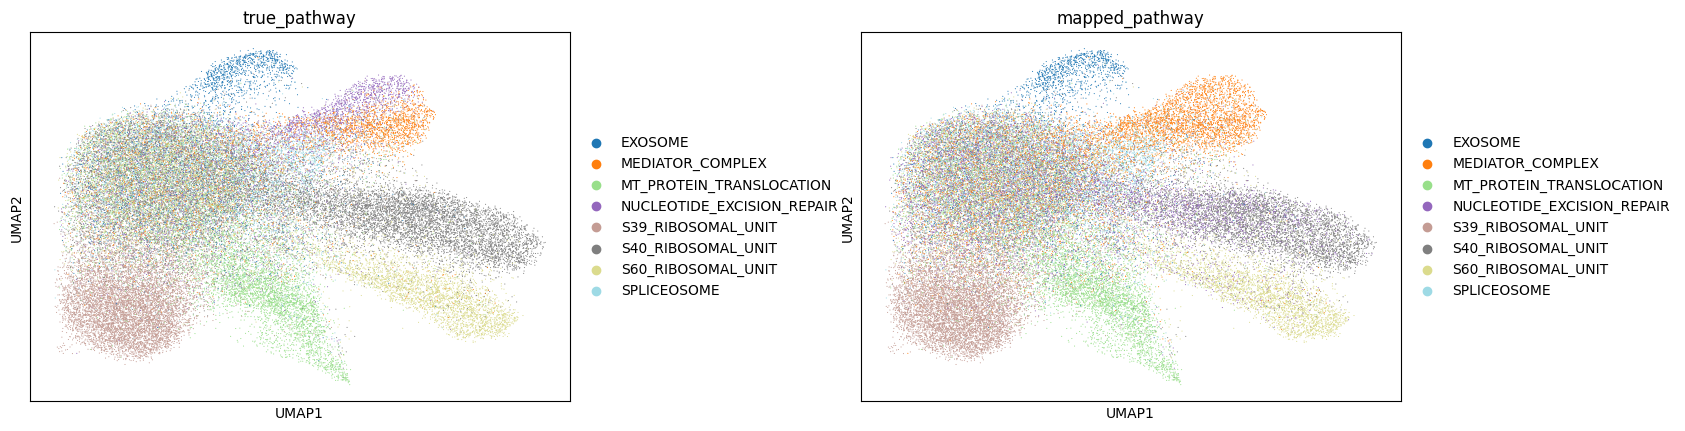

In [22]:
results_df = cluster_results['merged']
clustered_genes = results_df['gene'].unique()

z_sub = sub[sub.obs['pert'].isin(clustered_genes)].copy()
sc.pp.neighbors(z_sub, use_rep='z')
sc.tl.umap(z_sub)

from matplotlib.colors import to_hex

gene_to_true   = dict(zip(results_df['gene'], results_df['pathway']))
gene_to_mapped = dict(zip(results_df['gene'], results_df['mapped_pathway']))

z_sub.obs['true_pathway']   = z_sub.obs['pert'].map(gene_to_true)
z_sub.obs['mapped_pathway'] = z_sub.obs['pert'].map(gene_to_mapped)
z_sub = z_sub[z_sub.obs['mapped_pathway'].notna() & (z_sub.obs['mapped_pathway'] != 'NA')].copy()

all_cats  = pd.Index(np.unique(
    list(z_sub.obs['true_pathway'].dropna().unique()) +
    list(z_sub.obs['mapped_pathway'].dropna().unique())
))
cat_dtype = pd.api.types.CategoricalDtype(categories=all_cats, ordered=False)
z_sub.obs['true_pathway']   = z_sub.obs['true_pathway'].astype('string').astype(cat_dtype)
z_sub.obs['mapped_pathway'] = z_sub.obs['mapped_pathway'].astype('string').astype(cat_dtype)

cmap = plt.cm.get_cmap('tab20', len(all_cats))
shared_palette = {cat: to_hex(cmap(i)) for i, cat in enumerate(all_cats)}
z_sub.uns['true_pathway_colors']   = [shared_palette[c] for c in all_cats]
z_sub.uns['mapped_pathway_colors'] = [shared_palette[c] for c in all_cats]

sc.pl.umap(z_sub, color=['true_pathway', 'mapped_pathway'], wspace=0.4)